Epoch 0 Loss 0.4743812680244446
Epoch 500 Loss 1.4298313544713892e-05
Epoch 1000 Loss 5.093328127259156e-06
Epoch 1500 Loss 2.2080128019297263e-06
Epoch 2000 Loss 1.5579696537315613e-06
Epoch 2500 Loss 2.0396653326315572e-06
MSE: 9.213833973946133e-05


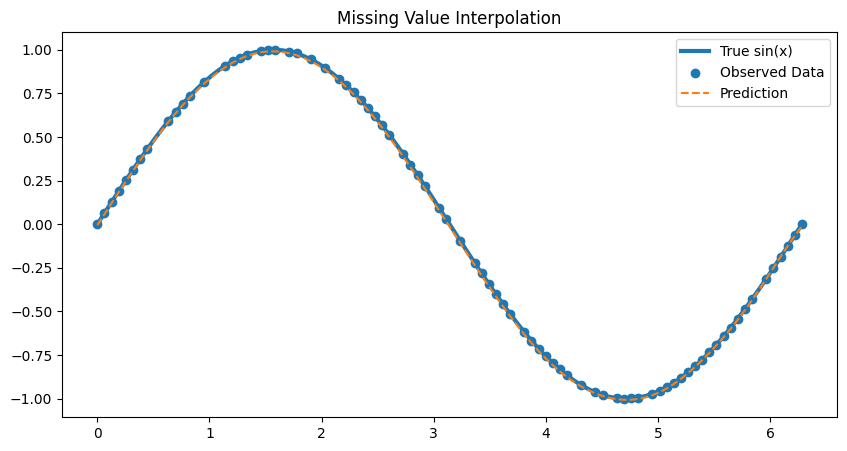

In [ ]:
#欠損値予測２次元グラフ 普通NNver（Neural ODE無し）

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================
# データ生成
# ============================================

x = np.linspace(0, 2*np.pi, 100)

y_true = np.sin(x)

# ============================================
# 欠損作成（null）
# ============================================

y_missing = y_true.copy()

# ランダムに20個欠損
missing_idx = np.random.choice(100, 20, replace=False)

y_missing[missing_idx] = np.nan

# mask作成
mask = ~np.isnan(y_missing)

# ============================================
# Tensor化
# ============================================

x_tensor = torch.tensor(x, dtype=torch.float32).view(-1,1)

y_tensor = torch.tensor(
    np.nan_to_num(y_missing, nan=0.0),
    dtype=torch.float32
).view(-1,1)

mask_tensor = torch.tensor(mask)

# ============================================
# 簡単なNN
# ============================================

model = nn.Sequential(
    nn.Linear(1,64),
    nn.Tanh(),

    nn.Linear(64,64),
    nn.Tanh(),

    nn.Linear(64,1)
)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

# ============================================
# 学習
# ============================================

epochs = 3000

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(x_tensor)

    # 欠損していない部分だけloss
    loss = criterion(
        pred[mask_tensor],
        y_tensor[mask_tensor]
    )

    loss.backward()

    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} Loss {loss.item()}")

# ============================================
# 推論
# ============================================

with torch.no_grad():
    y_pred = model(x_tensor).numpy()

# ============================================
# MSE計算
# ============================================

mse = np.mean((y_true - y_pred.flatten())**2)

print("MSE:", mse)

# ============================================
# 可視化
# ============================================

plt.figure(figsize=(10,5))

# 真値
plt.plot(x, y_true,
         label='True sin(x)',
         linewidth=3)

# 欠損データ
plt.scatter(
    x[mask],
    y_missing[mask],
    label='Observed Data'
)

# 予測
plt.plot(
    x,
    y_pred,
    '--',
    label='Prediction'
)

plt.legend()

plt.title("Missing Value Interpolation")

plt.show()

Epoch 0
Loss: 13.664047241210938
Epoch 500
Loss: 0.1381685882806778
Epoch 1000
Loss: 0.023667549714446068
Epoch 1500
Loss: 0.0126493526622653
Epoch 2000
Loss: 0.01165265217423439
Epoch 2500
Loss: 0.008646679110825062
MSE: 0.01289164774457023


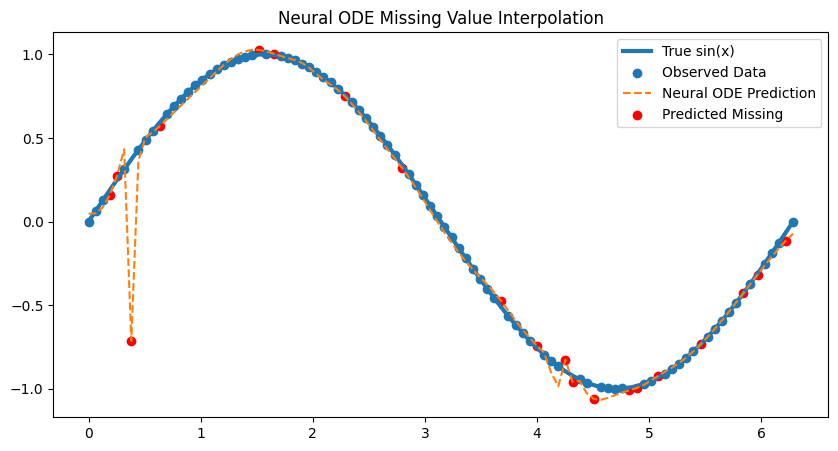

In [ ]:
#欠損値予測２次元グラフ Neural ODEver

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchdiffeq import odeint

# ============================================
# データ生成
# ============================================

x = np.linspace(0, 2*np.pi, 100)

y_true = np.sin(x)

# ============================================
# 欠損作成
# ============================================

y_missing = y_true.copy()

missing_idx = np.random.choice(100, 20, replace=False)

y_missing[missing_idx] = np.nan

mask = ~np.isnan(y_missing)

# ============================================
# Tensor化
# ============================================

x_tensor = torch.tensor(
    x,
    dtype=torch.float32
).view(-1,1)

y_tensor = torch.tensor(
    np.nan_to_num(y_missing, nan=0.0),
    dtype=torch.float32
).view(-1,1)

mask_tensor = torch.tensor(mask)

# ============================================
# ODE Function
# dh/dt = f(h,t)
# ============================================

class ODEFunc(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1,64),
            nn.Tanh(),

            nn.Linear(64,64),
            nn.Tanh(),

            nn.Linear(64,1)
        )

    def forward(self, t, h):

        return self.net(h)

# ============================================
# Neural ODE Model
# ============================================

class NeuralODEModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.odefunc = ODEFunc()

    def forward(self, x_input):

        # 初期値
        h0 = x_input

        # ODE時間
        t = torch.tensor([0,1]).float()

        # ODE solve
        out = odeint(
            self.odefunc,
            h0,
            t,
            method='rk4'
        )

        # 最終時刻
        return out[-1]

# ============================================
# モデル
# ============================================

model = NeuralODEModel()

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

# ============================================
# 学習
# ============================================

epochs = 3000

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(x_tensor)

    loss = criterion(
        pred[mask_tensor],
        y_tensor[mask_tensor]
    )

    loss.backward()

    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}")
        print("Loss:", loss.item())

# ============================================
# 推論
# ============================================

with torch.no_grad():

    y_pred = model(x_tensor).numpy()

# ============================================
# MSE
# ============================================

mse = np.mean(
    (y_true - y_pred.flatten())**2
)

print("MSE:", mse)

# ============================================
# 可視化
# ============================================

plt.figure(figsize=(10,5))

# 真値
plt.plot(
    x,
    y_true,
    label='True sin(x)',
    linewidth=3
)

# 観測点
plt.scatter(
    x[mask],
    y_missing[mask],
    label='Observed Data'
)

# 予測
plt.plot(
    x,
    y_pred,
    '--',
    label='Neural ODE Prediction'
)

# 欠損位置
plt.scatter(
    x[missing_idx],
    y_pred[missing_idx],
    color='red',
    label='Predicted Missing'
)

plt.legend()

plt.title("Neural ODE Missing Value Interpolation")

plt.show()